## Step 1: Initialization

In [1]:
import os
import sys
import datetime
import numpy as np
# Manual parameters

type_sub='obs'
width_sub='optm' # Be consistent with prepare jupyter file

total_neighbor_reach=[73254400131,73254400121,73254400111,73254400101]
choose_index=list(range(len(total_neighbor_reach)))
target_reachid=73254400101 # Be consistent with prepare jupyter file

first_day_orig=datetime.datetime(2023,8,5)
first_day_optm=datetime.datetime(2023,12,29) # Both in prepare jupyter file, used for validation and plotting
prior_width=67 # Only for plot
cali_A0_upper=1e9 # Will restrict later

S3_reachid=73254400101 # reconstructed reachid for Sentinel-3
use_measure=True # Whether to use SWOT-based slope to reconstruct discharge

scale_est=200 # For plotting y axis
usgs_id="02223248" # Use the latest USGS instead of those from SoS
calc_mode=True # True for calculate all stats, False for only plot

print('type_sub:',type_sub,', width_sub:',width_sub)

type_sub: obs , width_sub: optm


In [ ]:
# Jupyter paramters

if width_sub=='orig':
    first_day=first_day_orig
else:
    first_day=first_day_optm
begin_limit=(first_day_optm-first_day).days+1
# Use same time range for orig and optm

jupyter_path=os.path.dirname(os.path.abspath("__file__"))
src_path=os.path.join(os.path.dirname(jupyter_path),'src')
sys.path.append(src_path)
from total_imports import *
print('file path:',jupyter_path)
print('code path:',src_path)

jupyter_path=os.path.dirname(os.path.abspath("__file__"))
jupyter_obs_mode=(type_sub=='obs')
all_reachid=[total_neighbor_reach[i] for i in choose_index]
reach_index=int(np.where(np.array(all_reachid)==target_reachid)[0][0])

prior_path=r"path\to\your\SoS\na_sword_v16_SOS_unconstrained_0001_20240611T010141_priors.nc"
S3_json_path=r"path\to\your\S3json"
usgs_path=r"path\to\usgs\gauge"
# Ajust paths based on the current notebook location
result_path=prior_path.replace('priors','results')

file path: d:\Workstation\SWOT\discharge\calibration\sample_reach
code path: d:\Workstation\SWOT\discharge\calibration\src


In [3]:
# Import hydrocorn observations
RunDir=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub
filename=RunDir+ r'\df_reaches_hydrocorn_rechindex0.pkl'
with open(filename, 'rb') as input:
    df_reaches = pickle.load(input)
for i in range(len(df_reaches)):
    df_reaches[i] = df_reaches[i][df_reaches[i]['date'] >= first_day_optm]
    print(len(df_reaches[i]))

25
21
21
19


In [4]:
if calc_mode: # Recalculate everything

	RunDir=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub
	ObsFile= RunDir + r'\SWOTObs_by_us.txt'

	[DAll,Obs]=ReadObs(ObsFile,begin_limit)

	ParamFile= RunDir + r'\params_by_us.txt'
	[Chain,Prior,R,Exp]=ReadParams(ParamFile,DAll)

	# Read SoS parameters
	SoS_params=Getsos_calibration(DAll,all_reachid,
		target_reachid,
		prior_path=prior_path)

	# Lateral flow = 0
	Laterals=False
	if Laterals:
		LateralMeanFile = RunDir + r'\LateralsMean.txt'
		from ReadLats import ReadLats   
		Prior.AllLats.q=ReadLats(LateralMeanFile,DAll)     
		Prior.AllLats.qv=reshape(Prior.AllLats.q,(DAll.nR*(DAll.nt-1),1)  )
	else: 
		Prior.AllLats.q=zeros( (DAll.nR,DAll.nt)  )

	[D,Obs,AllObs,DAll,Prior.Lats.q]=SelObs(DAll,Obs,Exp,Prior.AllLats)
	Prior.Lats.qv=reshape(Prior.Lats.q,(D.nR*(D.nt-1),1)  )

	Obs=CalcdA(D,Obs)
	AllObs=CalcdA(DAll,AllObs)

	# Calculate prior parameters using MCMC
	DebugMode=False
	ShowFigs=False
	Use_sos=False
	[Prior,jmp]=ProcessPrior(Prior,AllObs,DAll,Obs,D,ShowFigs,Exp,R,SoS_params,DebugMode,Use_sos)
else: # Load previous results
	RunDir=jupyter_path+r'\PepsiSac_'+type_sub+'_'+width_sub
	filename=RunDir+ r'\RunData_nopt5.pkl'
	with open(filename, 'rb') as input:
		AllObs = pickle.load(input)
		Chain=pickle.load(input)
		D=pickle.load(input)
		DAll=pickle.load(input)
		Exp=pickle.load(input)            
		Laterals=pickle.load(input)                        
		Obs = pickle.load(input)        
		Prior = pickle.load(input)
		R = pickle.load(input)
		jmp = pickle.load(input)
		SoS_params= pickle.load(input)

nt= 18
Processing prior for reach 1 / 4 .
Reach 1, Iteration 0
Reach 1, Iteration 500
Reach 1, Iteration 1000
Reach 1, Iteration 1500
Reach 1, Iteration 2000
Reach 1, Iteration 2500
Reach 1, Iteration 3000
Reach 1, Iteration 3500
Reach 1, Iteration 4000
Reach 1, Iteration 4500
Reach 1, Iteration 5000
Reach 1, Iteration 5500
Reach 1, Iteration 6000
Reach 1, Iteration 6500
Reach 1, Iteration 7000
Reach 1, Iteration 7500
Reach 1, Iteration 8000
Reach 1, Iteration 8500
Reach 1, Iteration 9000
Reach 1, Iteration 9500
Processing prior for reach 2 / 4 .
Reach 2, Iteration 0
Reach 2, Iteration 500
Reach 2, Iteration 1000
Reach 2, Iteration 1500
Reach 2, Iteration 2000
Reach 2, Iteration 2500
Reach 2, Iteration 3000
Reach 2, Iteration 3500
Reach 2, Iteration 4000
Reach 2, Iteration 4500
Reach 2, Iteration 5000
Reach 2, Iteration 5500
Reach 2, Iteration 6000
Reach 2, Iteration 6500
Reach 2, Iteration 7000
Reach 2, Iteration 7500
Reach 2, Iteration 8000
Reach 2, Iteration 8500
Reach 2, Iteration 

In [5]:
# Use USGS data if available
if usgs_id is not None:
	with open(usgs_path,'r') as f:
		usgs_gauge=json.load(f)
	id=np.where(np.array(usgs_gauge['id'])==usgs_id)[0][0]
	gnew_time=np.array(usgs_gauge['time'][id])
	gnew_discharge=np.array(usgs_gauge['discharge'][id])
	gnew_time_datetime=np.array([datetime.datetime.strptime(gt, '%Y-%m-%d') for gt in gnew_time])
	SoS_params.gaugetime=gnew_time_datetime
	SoS_params.gaugedisg=gnew_discharge
SoS_params.sosA0

array([[-1.00000000e+12],
       [ 5.98222978e+01],
       [ 6.50193907e+01],
       [ 5.56497337e+01]])

In [6]:
# Check parameters
print('SoS A0:',SoS_params.sosA0)
print('SoS na:',SoS_params.sosna)
print('SoS x1:',SoS_params.sosx1)
print('MCMC prior A0:',Prior.meanA0)
print('MCMC prior na:',Prior.meanna)
print('MCMC prior x1:',Prior.meanx1)

SoS A0: [[-1.00000000e+12]
 [ 5.98222978e+01]
 [ 6.50193907e+01]
 [ 5.56497337e+01]]
SoS na: [[-1.00000000e+12]
 [ 2.98597875e-02]
 [ 2.99725785e-02]
 [ 3.02121949e-02]]
SoS x1: [[-1.00000000e+12]
 [ 3.41906439e-01]
 [ 2.89295404e-01]
 [ 2.81170502e-01]]
MCMC prior A0: [ 79.0532779  102.51894715 114.02829474  97.47793449]
MCMC prior na: [0.02994305 0.02998557 0.02997314 0.02997261]
MCMC prior x1: [0.33194601 0.48951539 0.41609208 0.48831155]


In [7]:
if calc_mode:
	[Obs,Prior]=GetCovMats(D,Obs,Prior) # Preprocess
	Obs.S[Obs.S<0]=putmask(Obs.S,Obs.S<0,0) # Limit slopes not negative
	AllObs.S[AllObs.S<0]=putmask(AllObs.S,AllObs.S<0,0)

## Step 2: MCMC

In [8]:
# MCMC calibration to get posterior parameters
A0_prior_list=[]
def one_iteration(iteration_step):
	A0_prior_list.append(Prior.meanA0[reach_index])
	cali_max_A0=np.array(Prior.meanA0)*2
	cali_max_A0[cali_max_A0>cali_A0_upper]=cali_A0_upper
	print(f"## Step {iteration_step}, cali_max_A0={cali_max_A0}")
	Chain_calc,jmp_calc=MetropolisCalculations(Prior,D,Obs,jmp,Chain,R,DAll,AllObs,Exp.nOpt,DebugMode,A0_max=cali_max_A0,output_path=None)
	return cali_max_A0, Chain_calc, jmp_calc
if calc_mode:
	iteration_step=0
	max_iter=1 # Can be adjusted later
	A0_prior_origin=Prior.meanA0.copy()
	
	min_loss=np.ones((D.nR,)) * 1e10
	best_A0_Prior=np.zeros_like(Prior.meanA0)
	while iteration_step<max_iter:
		iteration_step+=1
		cali_max_A0,Chain,jmp_calc=one_iteration(iteration_step)
		A0_prior=Prior.meanA0
		A0_post=np.array([find_peak_position(Chain.thetaA0[i,Chain.Nburn+1:Chain.N]) for i in range(len(Chain.thetaA0))])
		print("A0_prior:", A0_prior)
		print("A0_post:", A0_post)
		change_rate=np.abs(A0_post-A0_prior)/A0_prior
		MCMC_range=cali_max_A0-jmp.A0min[0]
		check_min=A0_post-MCMC_range*0.05
		check_max=A0_post+MCMC_range*0.05
		MCMC_A0=Chain.thetaA0[:,Chain.Nburn+1:Chain.N]
		MCMC_Theta=Chain.Theta[:,Chain.Nburn+1:Chain.N].reshape(len(MCMC_A0),D.nt-1,-1)
		
		print(f"MCMC_A0 shape: {MCMC_A0.shape}")
		print(f"check_min shape: {check_min.shape}")
		print(f"check_max shape: {check_max.shape}")
		print(f"MCMC_Theta shape: {MCMC_Theta.shape}")
		A0_condition= (MCMC_A0 > check_min[:, np.newaxis]) & (MCMC_A0 < check_max[:, np.newaxis])
		current_loss=np.mean(np.where(A0_condition[:, np.newaxis, :],MCMC_Theta,0)**2,axis=(1,2))
		print("Loss",current_loss)
		print("Change rate:", change_rate)

		plt.figure(figsize=(10, 5))
		plt.hist(Chain.thetaA0[reach_index,Chain.Nburn+1:Chain.N], bins=50, alpha=0.5)
		plt.savefig(RunDir+f"\\A0_Distribution_{iteration_step}.pdf")
		plt.close()

		plt.figure(figsize=(10, 5))
		plt.scatter(Chain.thetaA0[reach_index,Chain.Nburn+1:Chain.N], Chain.Theta[reach_index,Chain.Nburn+1:Chain.N], alpha=0.5)
		plt.savefig(RunDir+f"\\Theta_Scatter_{iteration_step}.pdf")
		plt.close()

		iter_mask=(change_rate>0.1) &(current_loss<min_loss*1.5)
		better_mask=current_loss<min_loss
		min_loss[better_mask]=current_loss[better_mask]
		best_A0_Prior[better_mask]=A0_prior[better_mask]
		if np.sum(iter_mask) == 0:
			break
		# break
		
		Prior.meanA0[iter_mask]=(A0_post[iter_mask]+A0_prior[iter_mask])*0.5
	Prior.meanA0=best_A0_Prior
	cali_max_A0,Chain,jmp_calc=one_iteration("Final")
	Prior.meanA0=A0_prior_origin
else:
	cali_max_A0=np.array(Prior.meanA0)*2

## Step 1, cali_max_A0=[158.1065558  205.03789431 228.05658949 194.95586898]
Iteration # 1/10000, A0 pointer at 0
Iteration # 1001/10000, A0 pointer at 2111
static eps value: 1.0000000000000002e-08
Iteration # 2001/10000, A0 pointer at 4183
Iteration # 3001/10000, A0 pointer at 6093
Iteration # 4001/10000, A0 pointer at 8174
Iteration # 5001/10000, A0 pointer at 10132
Iteration # 6001/10000, A0 pointer at 12139
Iteration # 7001/10000, A0 pointer at 14180
Iteration # 8001/10000, A0 pointer at 16238
Iteration # 9001/10000, A0 pointer at 18281
A0_prior: [ 79.0532779  102.51894715 114.02829474  97.47793449]
A0_post: [149.66828611 114.25278225 131.95975615 126.18071073]
MCMC_A0 shape: (4, 7999)
check_min shape: (4,)
check_max shape: (4,)
MCMC_Theta shape: (4, 17, 7999)
Loss [2.94742725e-06 4.73603156e-07 2.24725842e-07 3.05473216e-07]
Change rate: [0.89325845 0.11445528 0.15725449 0.29445409]
## Step Final, cali_max_A0=[158.1065558  205.03789431 228.05658949 194.95586898]
Iteration # 1/1000

In [9]:
# Calculate Theta distribution for plotting
p_A0 = Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N]
p_Theta = Chain.Theta.reshape(D.nR, D.nt-1, -1)[reach_index, :, Chain.Nburn+1:Chain.N]

A0_min = np.min(p_A0)
A0_max = np.max(p_A0)
n_bins = 100

A0_bins = np.linspace(A0_min, A0_max, n_bins + 1)
A0_centers = (A0_bins[:-1] + A0_bins[1:]) / 2

theta_medians_overall = np.full(n_bins, np.nan)
bin_counts = np.zeros(n_bins)

# Calculate median Theta for each A0 bin
for i in range(n_bins):
    mask = (p_A0 >= A0_bins[i]) & (p_A0 < A0_bins[i + 1])
    if i == n_bins - 1:
        mask = (p_A0 >= A0_bins[i]) & (p_A0 <= A0_bins[i + 1])
    bin_counts[i] = np.sum(mask)
    if bin_counts[i] > 0:
        theta_subset = p_Theta[:, mask]
        all_theta_values = theta_subset.flatten()
        valid_theta = all_theta_values[~np.isnan(all_theta_values)]
        if len(valid_theta) > 0:
            theta_medians_overall[i] = np.median(valid_theta)

# Statistics output
print(f"A0 range: {A0_min:.2f} - {A0_max:.2f}")
print(f"Divided into {n_bins} intervals")
print(f"Mean Sample: {np.mean(bin_counts[bin_counts > 0]):.1f}")

# Filter out intervals without data
valid_mask = ~np.isnan(theta_medians_overall)
valid_A0_centers = A0_centers[valid_mask]
valid_theta_medians = theta_medians_overall[valid_mask]


A0 range: 90.52 - 192.97
Divided into 100 intervals
Mean Sample: 82.5


<>:87: SyntaxWarning: invalid escape sequence '\T'
<>:87: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\4049528606.py:87: SyntaxWarning: invalid escape sequence '\T'
  ax2.set_ylabel('|$\Theta^2$|', fontsize=24)


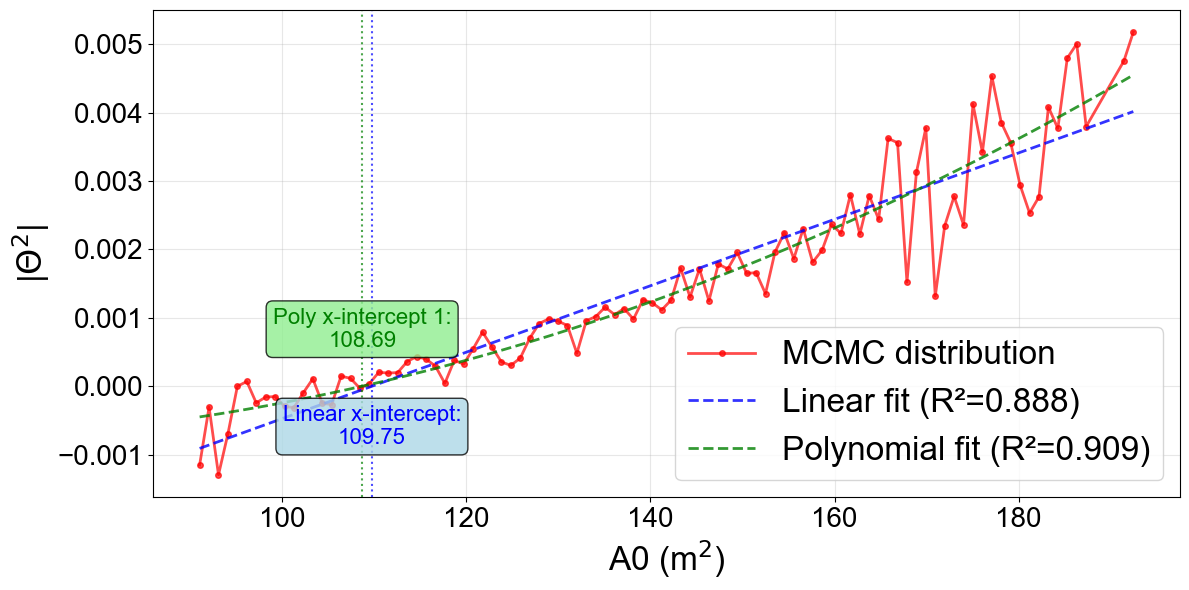

=== Results ===
Leanear fit:
  Slope: 0.000049
  Intercept: -0.005328
  R²: 0.887718
  x interception: 109.750011

Poly fit:
  R²: 0.908510
  与x轴交点: [np.float64(108.68835759547237)]

Theta range: -0.0013 - 0.0052
Theta mean: 0.0015
Theta var: 0.0015


In [10]:
# Plot Theta-A0 relationship curve
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax2 = plt.subplots(1, 1, figsize=(12, 6))

ax2.plot(valid_A0_centers, valid_theta_medians, 'o-', 
         color='red', linewidth=2, markersize=4, alpha=0.7, label='MCMC distribution')

mask = ~np.isnan(valid_A0_centers) & ~np.isnan(valid_theta_medians)
x_fit = valid_A0_centers[mask]
y_fit = valid_theta_medians[mask]

if len(x_fit) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
    x_range = np.linspace(np.min(x_fit), np.max(x_fit), 100)
    y_linear = slope * x_range + intercept
    
    if slope != 0:
        x_intercept_linear = -intercept / slope
    else:
        x_intercept_linear = np.nan
    
    ax2.plot(x_range, y_linear, '--', color='blue', linewidth=2, alpha=0.8, 
             label=f'Linear fit (R²={r_value**2:.3f})')
    
    try:
        poly_features = PolynomialFeatures(degree=2)
        poly_reg = Pipeline([
            ('poly', poly_features),
            ('linear', LinearRegression())
        ])
        poly_reg.fit(x_fit.reshape(-1, 1), y_fit)
        y_poly = poly_reg.predict(x_range.reshape(-1, 1))
        
        r2_poly = poly_reg.score(x_fit.reshape(-1, 1), y_fit)
        
        ax2.plot(x_range, y_poly, '--', color='green', linewidth=2, alpha=0.8,
                 label=f'Polynomial fit (R²={r2_poly:.3f})')
        
        poly_coef = poly_reg.named_steps['linear'].coef_
        poly_intercept = poly_reg.named_steps['linear'].intercept_
        
        a = poly_coef[2] if len(poly_coef) > 2 else 0
        b = poly_coef[1] if len(poly_coef) > 1 else 0
        c = poly_intercept
        
        if a != 0:
            discriminant = b**2 - 4*a*c
            if discriminant >= 0:
                x_intercept_poly1 = (-b + np.sqrt(discriminant)) / (2*a)
                x_intercept_poly2 = (-b - np.sqrt(discriminant)) / (2*a)
                x_intercepts_poly = [x for x in [x_intercept_poly1, x_intercept_poly2] 
                                   if np.min(x_fit) <= x <= np.max(x_fit)]
            else:
                x_intercepts_poly = []
        else:
            x_intercepts_poly = [-c/b] if b != 0 else []
            
    except Exception as e:
        print(f"Failed to fit: {e}")
        x_intercepts_poly = []
    
    if not np.isnan(x_intercept_linear):
        ax2.axvline(x=x_intercept_linear, color='blue', linestyle=':', alpha=0.7)
        ax2.text(x_intercept_linear, ax2.get_ylim()[0] + 0.1 * (ax2.get_ylim()[1] - ax2.get_ylim()[0]),
                f'Linear x-intercept:\n{x_intercept_linear:.2f}', 
                ha='center', va='bottom', fontsize=16, color='blue',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8))
    
    for i, x_int in enumerate(x_intercepts_poly):
        ax2.axvline(x=x_int, color='green', linestyle=':', alpha=0.7)
        ax2.text(x_int, ax2.get_ylim()[0] + 0.3 * (ax2.get_ylim()[1] - ax2.get_ylim()[0]),
                f'Poly x-intercept {i+1}:\n{x_int:.2f}', 
                ha='center', va='bottom', fontsize=16, color='green',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

ax2.set_xlabel('A0 (m$^2$)', fontsize=24)
ax2.set_ylabel('|$\Theta^2$|', fontsize=24)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.legend(fontsize=24)


plt.tight_layout()
plt.show()
plt.close()

print(f"=== Results ===")
print(f"Leanear fit:")
print(f"  Slope: {slope:.6f}")
print(f"  Intercept: {intercept:.6f}")
print(f"  R²: {r_value**2:.6f}")
print(f"  x interception: {x_intercept_linear:.6f}" if not np.isnan(x_intercept_linear) else "  no x interception")

if 'x_intercepts_poly' in locals() and x_intercepts_poly:
    print(f"\nPoly fit:")
    print(f"  R²: {r2_poly:.6f}")
    print(f"  与x轴交点: {x_intercepts_poly}")
else:
    print(f"\nno polynomial fit or no x intercepts")

# Output some statistics
print(f"\nTheta range: {np.nanmin(valid_theta_medians):.4f} - {np.nanmax(valid_theta_medians):.4f}")
print(f"Theta mean: {np.mean(valid_theta_medians):.4f}")
print(f"Theta var: {np.std(valid_theta_medians):.4f}")

In [11]:
# Check parameters

print('A0 Prior: ',Prior.meanA0)
print('A0 Posterior: ',np.mean(Chain.thetaA0[:,Chain.Nburn+1:Chain.N],1))
print('na Prior: ',Prior.meanna)
print('na Posterior: ',np.mean(Chain.thetana[:,Chain.Nburn+1:Chain.N],1))
print('x Prior: ',Prior.meanx1)
print('x Posterior: ',np.mean(Chain.thetax1[:,Chain.Nburn+1:Chain.N],1))

A0 Prior:  [ 79.0532779  102.51894715 114.02829474  97.47793449]
A0 Posterior:  [141.36743356 122.43803407 140.19471871 132.47248891]
na Prior:  [0.02994305 0.02998557 0.02997314 0.02997261]
na Posterior:  [0.02959784 0.03005254 0.03014337 0.03008105]
x Prior:  [0.33194601 0.48951539 0.41609208 0.48831155]
x Posterior:  [0.29225796 0.47701316 0.44990405 0.4625427 ]


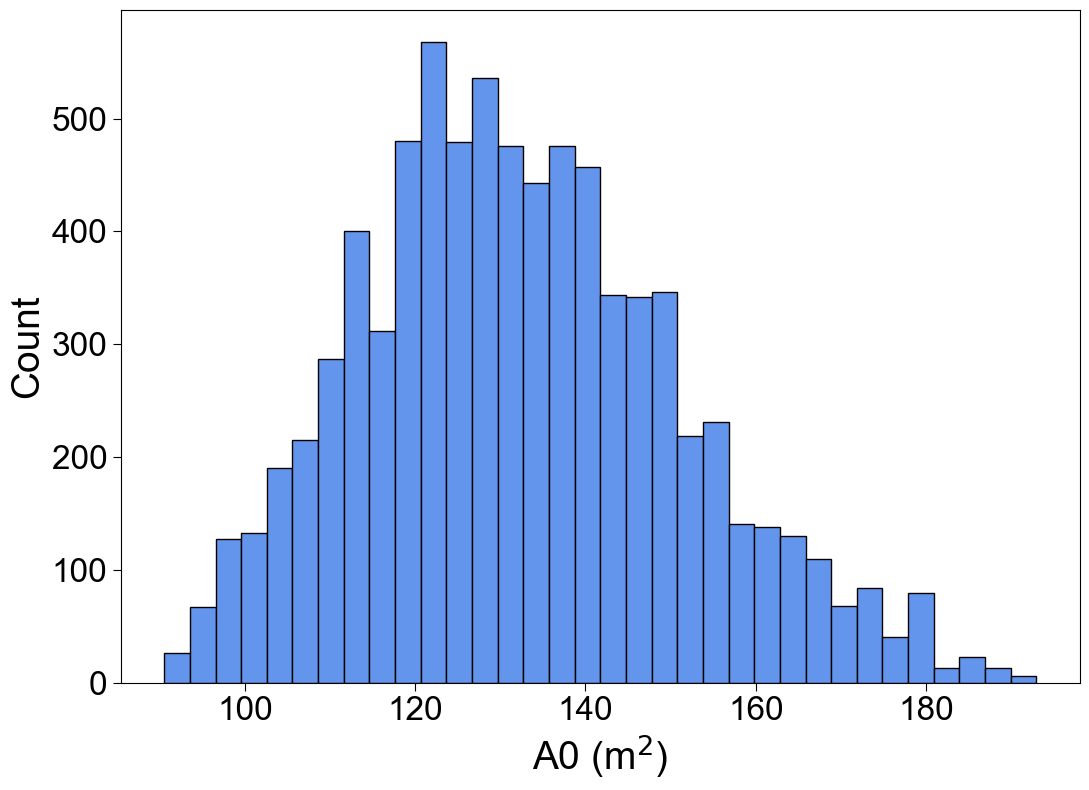

In [12]:
# Plot A0 distribution histogram
h_min = np.min(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N])
h_max = np.max(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N])
bins = np.linspace(h_min, h_max, 35)

plt.figure(figsize=(11, 8))
plt.hist(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N], bins=bins, color='#6495ED', edgecolor='black')

plt.xlabel('A0 (m$^2$)', fontsize=28)
plt.ylabel('Count', fontsize=28)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)  # y 轴数字字体
plt.tick_params(axis='both', which='major', length=6)

plt.tight_layout()
plt.show()

## Step 3: Discharge Estimation

In [13]:
# Estimate discharge
[Estimate,Chain]=CalculateEstimates(Chain,D,Obs,Prior,DAll,AllObs,Exp.nOpt)
# Kalman filter, optional
Estimate = FilterEstimate(Estimate,Chain,D,Obs)

In [14]:
# Save parameters
filename=RunDir+ f'\RunData_nopt{Exp.nOpt}.pkl'
with open(filename, 'wb') as output:
    pickle.dump(AllObs, output, pickle.HIGHEST_PROTOCOL)
    pickle.dump(Chain,output,pickle.HIGHEST_PROTOCOL)
    pickle.dump(D,output,pickle.HIGHEST_PROTOCOL)
    pickle.dump(DAll,output,pickle.HIGHEST_PROTOCOL)
    pickle.dump(Exp,output,pickle.HIGHEST_PROTOCOL)     
    pickle.dump(Laterals,output,pickle.HIGHEST_PROTOCOL)                 
    pickle.dump(Obs, output, pickle.HIGHEST_PROTOCOL)
    pickle.dump(Prior, output, pickle.HIGHEST_PROTOCOL)   
    pickle.dump(R, output, pickle.HIGHEST_PROTOCOL)      
    pickle.dump(jmp, output, pickle.HIGHEST_PROTOCOL)
    pickle.dump(SoS_params, output, pickle.HIGHEST_PROTOCOL)

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\2967213020.py:2: SyntaxWarning: invalid escape sequence '\R'
  filename=RunDir+ f'\RunData_nopt{Exp.nOpt}.pkl'


In [15]:
# Match and validate
def calculate_stat(gauge_discharge, metro_disg):
    CC, _=pearsonr(gauge_discharge, metro_disg)
    NRMSE = np.sqrt(np.mean((gauge_discharge - metro_disg)**2)) / np.mean(gauge_discharge)
    rRMSE=np.sqrt(np.mean( (  (gauge_discharge-metro_disg)/gauge_discharge   )**2 ) )
    NRMSE2 = np.sqrt(np.mean((gauge_discharge - metro_disg)**2)) / (np.max(gauge_discharge)-np.min(gauge_discharge))
    NSE = 1 - (np.sum((gauge_discharge - metro_disg)**2) / np.sum((gauge_discharge - np.mean(gauge_discharge))**2))
    return CC, NRMSE, rRMSE, NRMSE2, NSE


def match_gauge_days(SoS_params,DAll,Estimate,first_day,reach_index,use_prior_scalor=True,use_posterior_scalor=True):
    gauge_datetime=SoS_params.gaugetime
    gauge_discharge=SoS_params.gaugedisg
    
    datetime_index = gauge_datetime>=first_day
    
    gauge_datetime=gauge_datetime[datetime_index]
    gauge_discharge=gauge_discharge[datetime_index]
    gauge_days=[]
    
    for gauge_date in gauge_datetime:
        gauge_days.append((gauge_date-first_day).days+1)
    
    corresponding_days=np.intersect1d(gauge_days, DAll.t)
    corresponding_gauge_disg=gauge_discharge[np.isin(gauge_days,corresponding_days)]
    corresponding_gauge_date=gauge_datetime[np.isin(gauge_days,corresponding_days)]
    
    inverse_days= DAll.t[0]
    prior_disg=Estimate.QhatPrior[reach_index,:]
    posterior_disg=Estimate.AllQ_peak[reach_index,:]
    posterior_disg2=Estimate.QhatPostf[reach_index,:]
    
    isin_index=np.isin(inverse_days, corresponding_days)
    prior_disg_c=prior_disg[isin_index]
    posterior_disg_c=posterior_disg[isin_index]
    posterior_disg2_c=posterior_disg2[isin_index]
    if use_prior_scalor:
        scale_factor_prior=SoS_params.WBM_discharge/np.mean(prior_disg_c)
    else:
        scale_factor_prior=1

    if use_posterior_scalor:
        scale_factor_posterior=SoS_params.WBM_discharge/np.mean(posterior_disg_c)
        scale_factor_posterior2=SoS_params.WBM_discharge/np.mean(posterior_disg2_c)
    else:
        scale_factor_posterior=1
        scale_factor_posterior2=1

    inverse_dates=[first_day+datetime.timedelta(days= day-1) for day in inverse_days]
    prior_stats = f'NSE: {calculate_stat(corresponding_gauge_disg, prior_disg_c*scale_factor_prior)[4]:.2f} NRMSE: {calculate_stat(corresponding_gauge_disg, prior_disg_c*scale_factor_prior)[3]*100:.0f} %'
    posterior_stats = f'NSE: {calculate_stat(corresponding_gauge_disg, posterior_disg_c*scale_factor_posterior)[4]:.2f} NRMSE: {calculate_stat(corresponding_gauge_disg, posterior_disg_c*scale_factor_posterior)[3]*100:.0f} %'
    kalman_stats = f'NSE: {calculate_stat(corresponding_gauge_disg, posterior_disg2_c*scale_factor_posterior2)[4]:.2f} NRMSE: {calculate_stat(corresponding_gauge_disg, posterior_disg2_c*scale_factor_posterior2)[3]*100:.0f} %'
    return inverse_dates,scale_factor_prior,scale_factor_posterior,scale_factor_posterior2,prior_stats,posterior_stats,kalman_stats

In [16]:
# Estimate uncertainty
Qtotal_uncertainty= Estimate.QstdPost

In [17]:
# Plot overall period
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator



gauge_datetime=SoS_params.gaugetime
gauge_discharge=SoS_params.gaugedisg
inverse_dates,scale_factor_prior,scale_factor_posterior,scale_factor_posterior2,prior_stats,posterior_stats,kalman_stats=match_gauge_days(SoS_params,DAll,Estimate,first_day,reach_index,
                                                                                     use_prior_scalor=False,use_posterior_scalor=False)

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
Qtotal_uncertainty_reach=Qtotal_uncertainty[reach_index,:]

fig, ax= plt.subplots(1,1, figsize=(8,4.5))

ax.plot(gauge_datetime,gauge_discharge,color='gray',linestyle='--', label='In-situ',alpha=0.7,linewidth=1.5)
ax.plot(inverse_dates,Estimate.QhatPrior[reach_index,:]*scale_factor_prior,color='#4C9F70',linestyle='-'
        ,label='Prior parameter based',marker='o',markersize=6,alpha=1,linewidth=1)

ax.plot(inverse_dates,Estimate.AllQ_peak[reach_index,:]*scale_factor_posterior,color='#CF6679',linestyle='-'
        ,label='Posterior parameter based',marker='o',markersize=6,alpha=1,linewidth=1)

ax.fill_between(inverse_dates, 
                (Estimate.AllQ[reach_index,:] - Qtotal_uncertainty_reach)*scale_factor_posterior,
                (Estimate.AllQ[reach_index,:] + Qtotal_uncertainty_reach)*scale_factor_posterior,
                color='#CF6679', alpha=0.2)

ax.plot(inverse_dates,Estimate.QhatPostf[reach_index,:]*scale_factor_posterior2,color='#5C7AEA',linestyle='-',
        label='Posterior parameter based (Kalman Filtered)',marker='o',markersize=6,alpha=1,linewidth=1)

plot_y_max=gauge_discharge[gauge_datetime>first_day].max()*1.1
plot_y_max=max(plot_y_max,np.nanmax(Estimate.AllQ[reach_index,:]*scale_factor_posterior)*1.1)
plot_y_max=max(plot_y_max,np.nanmax(Estimate.QhatPrior[reach_index,:]*scale_factor_prior)*1.1)
plot_y_max=max(plot_y_max,np.nanmax(Estimate.QhatPostf[reach_index,:]*scale_factor_posterior2)*1.1)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m$^3$/s)', fontsize=12)
ax.tick_params(labelsize=12)
ax.tick_params(which='major', length=5, width=1)
ax.set_title(f'Reach: {target_reachid} Prior width: {prior_width:.0f} m',fontsize=13)
x_pos = min(inverse_dates)+datetime.timedelta(days=240)
y_pos = plot_y_max*0.8
y_pos_delta=scale_est*0.8
ax.text(x_pos, y_pos, prior_stats, va='top', fontsize=12, color='#4C9F70')  # Green color for prior
ax.text(x_pos, y_pos-y_pos_delta, posterior_stats, va='top', fontsize=12, color='#CF6679')  # Red color for posterior
ax.text(x_pos, y_pos-y_pos_delta*2, kalman_stats, va='top', fontsize=12, color='#5C7AEA')  # Blue color for Kalman filtered
ax.set_xlim([np.min(inverse_dates)-datetime.timedelta(days=50),np.max(inverse_dates)+datetime.timedelta(days=50)])
ax.set_ylim([-plot_y_max*0.04, plot_y_max])

date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)
ax.yaxis.set_major_locator(MultipleLocator(int(plot_y_max//(scale_est*4))*scale_est))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=120))

# plt.legend(fontsize=10.5)
plt.tight_layout() # not show
#Save the figure
Save_path=RunDir+f'\SWOT_discharge_cal_nopt{Exp.nOpt}_NSE.pdf'
fig.savefig(Save_path, dpi=1000, bbox_inches='tight', bbox_extra_artists=(ax,))
plt.close()
# plt.show()

<>:61: SyntaxWarning: invalid escape sequence '\S'
<>:61: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\3775554399.py:61: SyntaxWarning: invalid escape sequence '\S'
  Save_path=RunDir+f'\SWOT_discharge_cal_nopt{Exp.nOpt}_NSE.pdf'


In [18]:
# Estimate all for target reach
Estimate_hydrocorn=CalculateEstimates_hydrocorn(df_reaches[reach_index],AllObs,Chain,Estimate, Prior,first_day,reach_index,Exp.nOpt,use_peak=True)
Q_uncertainty_reach=Estimate_hydrocorn.stdQ_obs

In [19]:
# Match and validate of total period
def calculate_stat(gauge_discharge, metro_disg):
    CC, _=pearsonr(gauge_discharge, metro_disg)
    NRMSE = np.sqrt(np.mean((gauge_discharge - metro_disg)**2)) / np.mean(gauge_discharge)
    rRMSE=np.sqrt(np.mean( (  (gauge_discharge-metro_disg)/gauge_discharge   )**2 ) )
    NRMSE2 = np.sqrt(np.mean((gauge_discharge - metro_disg)**2)) / (np.max(gauge_discharge)-np.min(gauge_discharge))
    NSE = 1 - (np.sum((gauge_discharge - metro_disg)**2) / np.sum((gauge_discharge - np.mean(gauge_discharge))**2))
    return CC, NRMSE, rRMSE, NRMSE2, NSE

def match_gauge_posterior(SoS_params,Estimate_hydrocorn, use_scalor=True, obs_mode=True):
    gauge_datetime=SoS_params.gaugetime
    gauge_discharge=SoS_params.gaugedisg
    
    hydro_dates= Estimate_hydrocorn.date_t
    if obs_mode:
        hydro_disgs= Estimate_hydrocorn.Qpeak_obs
    else:
        hydro_disgs= Estimate_hydrocorn.Q_fit
    corresponding_index=np.isin(hydro_dates.tolist(), gauge_datetime)
    hydro_date_corresponding= hydro_dates[corresponding_index]
    hydro_disg_corresponding= hydro_disgs[corresponding_index]
    
    corresponding_index=np.isin(gauge_datetime, hydro_dates.tolist())
    gauge_disg_corresponding=gauge_discharge[corresponding_index]
    
    mask = ~np.isnan(gauge_disg_corresponding) & ~np.isnan(hydro_disg_corresponding)
    gauge_disg_corresponding=gauge_disg_corresponding[mask]
    hydro_disg_corresponding=hydro_disg_corresponding[mask]
    hydro_date_corresponding=hydro_date_corresponding[mask]

    if use_scalor:
        scale_factor=SoS_params.WBM_discharge/np.mean(hydro_disg_corresponding)
    else:
        scale_factor=1
    hydro_disg_corresponding=hydro_disg_corresponding*scale_factor
    validate_posterior_text= f'NSE: {calculate_stat(gauge_disg_corresponding, hydro_disg_corresponding)[4]:.2f}  NRMSE: {calculate_stat(gauge_disg_corresponding, hydro_disg_corresponding)[3]*100:.0f} %'

    return hydro_dates, hydro_disgs, validate_posterior_text, scale_factor

def match_gauge_prior(SoS_params,Estimate_hydrocorn, use_scalor=True, obs_mode=True):
    gauge_datetime=SoS_params.gaugetime
    gauge_discharge=SoS_params.gaugedisg
    
    hydro_dates= Estimate_hydrocorn.date_t
    if obs_mode:
        hydro_disgs= Estimate_hydrocorn.Q_pobs
    else:
        hydro_disgs= Estimate_hydrocorn.Q_pfit
    corresponding_index=np.isin(hydro_dates.tolist(), gauge_datetime)
    hydro_date_corresponding= hydro_dates[corresponding_index]
    hydro_disg_corresponding= hydro_disgs[corresponding_index]
    
    corresponding_index=np.isin(gauge_datetime, hydro_dates.tolist())
    gauge_disg_corresponding=gauge_discharge[corresponding_index]
    
    mask = ~np.isnan(gauge_disg_corresponding) & ~np.isnan(hydro_disg_corresponding)
    gauge_disg_corresponding=gauge_disg_corresponding[mask]
    hydro_disg_corresponding=hydro_disg_corresponding[mask]
    hydro_date_corresponding=hydro_date_corresponding[mask]

    if use_scalor:
        scale_factor=SoS_params.WBM_discharge/np.mean(hydro_disg_corresponding)
    else:
        scale_factor=1
    hydro_disg_corresponding=hydro_disg_corresponding*scale_factor
    validate_prior_text= f'NSE: {calculate_stat(gauge_disg_corresponding, hydro_disg_corresponding)[4]:.2f}  NRMSE: {calculate_stat(gauge_disg_corresponding, hydro_disg_corresponding)[3]*100:.0f} %'

    return hydro_dates, hydro_disgs, validate_prior_text, scale_factor

In [20]:
# Plot total period
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

gauge_datetime=SoS_params.gaugetime
gauge_discharge=SoS_params.gaugedisg
hydro_dates, hydro_disgs, validate_posterior_text, scale_factor=match_gauge_posterior(SoS_params,Estimate_hydrocorn, use_scalor=False, obs_mode=jupyter_obs_mode)
hydro_dates_prior, hydro_disgs_prior, validate_prior_text, scale_factor_prior=match_gauge_prior(SoS_params,Estimate_hydrocorn, use_scalor=False, obs_mode=jupyter_obs_mode)


fig, ax= plt.subplots(1,1, figsize=(8,4.5))

ax.plot(gauge_datetime,gauge_discharge,color='gray',linestyle='--', label='In-situ',alpha=0.7,linewidth=1.5)
ax.plot(SoS_params.product_time,SoS_params.product_disg,color='purple',linestyle='--', label='Product',marker='o',markersize=6,alpha=1,linewidth=1)


ax.plot(hydro_dates_prior,hydro_disgs_prior*scale_factor_prior,color='#4C9F70',linestyle='-'
        ,label='Prior parameter based',marker='o',markersize=6,alpha=1,linewidth=1)
ax.plot(hydro_dates,hydro_disgs*scale_factor,color='#CF6679',linestyle='-'
        ,label='Posterior parameter based',marker='o',markersize=6,alpha=1,linewidth=1)
ax.fill_between(hydro_dates, 
                (hydro_disgs - Q_uncertainty_reach)*scale_factor,
                (hydro_disgs + Q_uncertainty_reach)*scale_factor,
                color='#CF6679', alpha=0.2)
'''
ax.errorbar(S3_dates, S3_disgs*scale_factor, 
        yerr=error,  # Add error bars using the standard deviation
        color='#CF6679', 
        fmt='o',  # 'o' for circular markers
        label='S3 Reconstruction',
        markersize=6, 
        alpha=1,
        linewidth=1,
        capsize=5)  # Adds caps to the error bars
'''
plot_y_max=gauge_discharge[gauge_datetime>first_day].max()*1.1
plot_y_max=max(plot_y_max,np.nanmax(hydro_disgs*scale_factor)*1.1)
plot_y_max=max(plot_y_max,np.nanmax(hydro_disgs_prior*scale_factor_prior)*1.1)
# ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m$^3$/s)', fontsize=16)
ax.tick_params(labelsize=12)
ax.tick_params(which='major', length=5, width=1)
ax.set_title(f'Reach ID: {target_reachid} Prior width: {prior_width:.0f} m',fontsize=18)
ax.set_xlim([np.min(hydro_dates)-datetime.timedelta(days=50),np.max(hydro_dates)+datetime.timedelta(days=50)])
ax.set_ylim([-plot_y_max*0.04,plot_y_max ])

# x_pos = min(hydro_dates)+datetime.timedelta(days=120)
y_pos = plot_y_max*0.8
# y_pos_delta=80
ax.text(x_pos, y_pos, validate_prior_text, va='top', fontsize=16, ha='left', color='#4C9F70')
ax.text(x_pos, y_pos-y_pos_delta, validate_posterior_text, va='top', fontsize=16, ha='left', color='#CF6679')

date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)
ax.yaxis.set_major_locator(MultipleLocator(int(plot_y_max//(scale_est*4))*scale_est))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=90))

plt.xticks(rotation=20)
# plt.legend(fontsize=10.5,loc='upper right')
plt.tight_layout()
#Save the figure
Save_path=RunDir+f'\SWOT_discharge_whole_nopt{Exp.nOpt}_NSE.pdf'
fig.savefig(Save_path, dpi=1000, bbox_inches='tight', bbox_extra_artists=(ax,))
plt.close()
# plt.show()

<>:62: SyntaxWarning: invalid escape sequence '\S'
<>:62: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\3727334061.py:62: SyntaxWarning: invalid escape sequence '\S'
  Save_path=RunDir+f'\SWOT_discharge_whole_nopt{Exp.nOpt}_NSE.pdf'


In [21]:
# Calculate NSE-A0 relationship
A0_min=jmp.A0min[0][reach_index]
A0_max=cali_max_A0[reach_index]

if calc_mode:
	test_A0=np.linspace(A0_min, A0_max, 200)
	test_NSE=[]
	prior_a0_copy=Prior.meanA0.copy()
	for A0 in test_A0:
		Prior.meanA0[reach_index]=A0
		Estimate_hydrocorn=CalculateEstimates_hydrocorn(df_reaches[reach_index],AllObs,Chain,Estimate, Prior,first_day,reach_index,Exp.nOpt)
		_,_,text,_=match_gauge_prior(SoS_params,Estimate_hydrocorn, use_scalor=False, obs_mode=jupyter_obs_mode)
		NSE=float(text.split()[1])
		test_NSE.append(NSE)
	test_NSE=np.array(test_NSE)
	Prior.meanA0=prior_a0_copy
	with open(RunDir+f'\\test_A0_NSE_nopt{Exp.nOpt}.pkl', 'wb') as output:
		pickle.dump(test_A0, output, pickle.HIGHEST_PROTOCOL)
		pickle.dump(test_NSE, output, pickle.HIGHEST_PROTOCOL)
else:
	with open(RunDir+f'\\test_A0_NSE_nopt{Exp.nOpt}.pkl', 'rb') as input:
		test_A0 = pickle.load(input)
		test_NSE = pickle.load(input)
Estimate_hydrocorn=CalculateEstimates_hydrocorn(df_reaches[reach_index],AllObs,Chain,Estimate, Prior,first_day,reach_index,Exp.nOpt,use_peak=True)
_,_,text_pr,_=match_gauge_prior(SoS_params,Estimate_hydrocorn, use_scalor=False, obs_mode=jupyter_obs_mode)
nse_pr=float(text_pr.split()[1])
a0_pr=Prior.meanA0[reach_index]
_,_,text_po,_=match_gauge_posterior(SoS_params,Estimate_hydrocorn, use_scalor=False, obs_mode=jupyter_obs_mode)
nse_po=float(text_po.split()[1])
a0_po=find_peak_position(Chain.thetaA0[reach_index,Chain.Nburn+1:Chain.N])
print(a0_pr,a0_po)
print(nse_pr,nse_po)


97.47793448999963 126.18071072956967
0.48 0.89


In [22]:
# Plot NSE-A0 curve
h_min = np.min(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N])
h_max = np.max(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N])
bins = np.linspace(h_min, h_max, 35)

plt.figure(figsize=(12, 8))
ax1 = plt.gca()
ax1.hist(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N], bins=bins, color='#848484', edgecolor='none',alpha=0.6)

ax1.set_xlabel('A0 (m$^2$)', fontsize=32)
ax1.set_ylabel('Count', fontsize=32)

ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.tick_params(axis='both', which='major', length=6)

ax2= ax1.twinx()

A0_mask=test_NSE>np.max(test_NSE)-2
t_A0=test_A0[A0_mask]
t_NSE=test_NSE[A0_mask]
t_NSE_smooth = np.convolve(t_NSE, np.ones(5)/5, mode='same')

ax2.plot(t_A0[3:-3], t_NSE_smooth[3:-3], linestyle='-', color='#B46DA9', label='NSE', linewidth=4)
ax2.scatter(a0_pr, nse_pr, color='#4C9F70',marker='^', s=450, label='Prior A0', edgecolor='black',zorder=10)
ax2.scatter(a0_po, nse_po, color='#CF6679',marker='*', s=750, label='Posterior A0', edgecolor='black',zorder=10)

ax2.set_ylabel('NSE', fontsize=32, color='#B46DA9')  #
ax2.tick_params(axis='y', labelcolor='#B46DA9')

ax2.tick_params(axis='y', labelsize=24, colors='#B46DA9')
ax1.tick_params(axis='both', which='major', length=6)

plt.tight_layout()
#Save the figure
Save_path=RunDir+f'\SWOT_discharge_{Exp.nOpt}_NSE_Curve.pdf'
plt.savefig(Save_path, dpi=1000, bbox_inches='tight', bbox_extra_artists=(ax,))
plt.close()
# plt.show()


<>:36: SyntaxWarning: invalid escape sequence '\S'
<>:36: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\385890183.py:36: SyntaxWarning: invalid escape sequence '\S'
  Save_path=RunDir+f'\SWOT_discharge_{Exp.nOpt}_NSE_Curve.pdf'


In [23]:
with open(r'..\o.txt','w') as f:
    f.write(Chain.thetaA0[reach_index, Chain.Nburn+1:Chain.N].tolist().__str__() + '\n')

## Step 4: S3 Reconstruction

In [24]:
# Read S3 observation and estimate
S3_obs_path=RunDir+'/S3_obs_noHcor.txt'
reach_index_S3=int(np.where(np.array(all_reachid)==S3_reachid)[0][0])
S3_constru=ReadS3(S3_obs_path,DAll,AllObs,Estimate, Chain,first_day,reach_index_S3,Exp.nOpt)
# Warning means negative A

dA2_before [-106.46366902  -98.74704458  -45.54940612 -100.44539899  -54.44717424
 -101.67345164  -62.61887632  -85.37554     -86.13908708  -46.96984486
   14.31148219  -65.50107513  -48.77494481  -78.15713297  -71.3393607
  -78.42216031  -99.49373781  -34.8182693   -23.31512637  -56.25753783
   -5.09053591  -29.2285304   -31.6260431   -93.14799932  -99.92165308
  -91.79229303  -85.94902685  -21.64743019  -79.53273583  -80.25324309
  -82.09837649  -19.59001496   -8.6748952   -46.84623549  -19.36653224
  -70.83285555  -69.66344363  -65.16356519  -52.03688027  -74.01329253
  -58.03421589   -6.98473946  -23.42767979  -13.42242988  -40.59933624
  -97.33845852  -79.98935914 -102.56011702 -106.29936908  -28.83025197
   21.82553261  -69.6380114   -76.93173548]
dA2_after [-47.27403869 -53.24067262 -53.67198858 -93.63491841 -87.46315068
 -93.06372958 -66.3002996 ]
nhat [0.03472468 0.03471885 0.03274232 0.03476526 0.03297516 0.034788
 0.03322387 0.03413337 0.03416905 0.03277712 0.03125737 0.0331

d:\Workstation\SWOT\discharge\calibration\src\ReadS3.py:94: RuntimeWarning: invalid value encountered in power
  S3_constru.thetaQ_ms[i,:]=1/nhat_all[i,:]*(Chain.thetaA0[target_reach_index,i]\
d:\Workstation\SWOT\discharge\calibration\src\ReadS3.py:96: RuntimeWarning: invalid value encountered in power
  S3_constru.thetaQ_ps[i,:]=1/nhat_all[i,:]*(Chain.thetaA0[target_reach_index,i]\
d:\Workstation\SWOT\discharge\calibration\src\ReadS3.py:96: ComplexWarning: Casting complex values to real discards the imaginary part
  S3_constru.thetaQ_ps[i,:]=1/nhat_all[i,:]*(Chain.thetaA0[target_reach_index,i]\


In [25]:
# Save estimation results
filename=RunDir+ f'\EstData_nopt{Exp.nOpt}.pkl'
with open(filename, 'wb') as output:
    pickle.dump(Estimate, output, pickle.HIGHEST_PROTOCOL)
    pickle.dump(S3_constru, output, pickle.HIGHEST_PROTOCOL)
    pickle.dump(Estimate_hydrocorn, output, pickle.HIGHEST_PROTOCOL)

<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\3529878916.py:2: SyntaxWarning: invalid escape sequence '\E'
  filename=RunDir+ f'\EstData_nopt{Exp.nOpt}.pkl'


In [26]:
# Update in-situ measurements
if usgs_id is not None:
	usgs_full_path=usgs_path.replace('gauge_swot.json','gauge_total.json')
	with open(usgs_full_path,'r') as f:
		usgs_gauge=json.load(f)
	id=np.where(np.array(usgs_gauge['id'])==usgs_id)[0][0]
	gnew_time=np.array(usgs_gauge['time'][id])
	gnew_discharge=np.array(usgs_gauge['discharge'][id])
	gnew_time_datetime=np.array([datetime.datetime.strptime(gt, '%Y-%m-%d') for gt in gnew_time])
	SoS_params.gaugetime=gnew_time_datetime
	SoS_params.gaugedisg=gnew_discharge
	

In [27]:
# Match and validate of S3 reconstruction
def calculate_stat(gauge_discharge, metro_disg):
    CC, _=pearsonr(gauge_discharge, metro_disg)
    NRMSE = np.sqrt(np.mean((gauge_discharge - metro_disg)**2)) / np.mean(gauge_discharge)
    rRMSE=np.sqrt(np.mean( (  (gauge_discharge-metro_disg)/gauge_discharge   )**2 ) )
    NRMSE2 = np.sqrt(np.mean((gauge_discharge - metro_disg)**2)) / (np.max(gauge_discharge)-np.min(gauge_discharge))
    NSE = 1 - (np.sum((gauge_discharge - metro_disg)**2) / np.sum((gauge_discharge - np.mean(gauge_discharge))**2))
    return CC, NRMSE, rRMSE, NRMSE2, NSE

def match_gauge_S3_poster(SoS_params,S3_constru, use_scalor=True, use_measured_slope=True):
    gauge_datetime=SoS_params.gaugetime
    gauge_discharge=SoS_params.gaugedisg
    
    S3_dates= S3_constru.date_t
    if use_measured_slope:
        S3_disgs= S3_constru.Q_ms
    else:
        S3_disgs= S3_constru.Q_ps
    corresponding_index=np.isin(S3_dates, gauge_datetime)
    S3_date_corresponding= S3_dates[corresponding_index]
    S3_disg_corresponding= S3_disgs[corresponding_index]
    
    corresponding_index=np.isin(gauge_datetime, S3_dates)
    gauge_disg_corresponding=gauge_discharge[corresponding_index]
    
    mask = ~np.isnan(gauge_disg_corresponding) & ~np.isnan(S3_disg_corresponding)
    gauge_disg_corresponding=gauge_disg_corresponding[mask]
    S3_disg_corresponding=S3_disg_corresponding[mask]
    S3_date_corresponding=S3_date_corresponding[mask]

    if use_scalor:
        scale_factor=SoS_params.WBM_discharge/np.mean(S3_disg_corresponding)
    else:
        scale_factor=1
    S3_disg_corresponding=S3_disg_corresponding*scale_factor
    validate_text= f'NSE: {calculate_stat(gauge_disg_corresponding, S3_disg_corresponding)[4]:.2f}  NRMSE: {calculate_stat(gauge_disg_corresponding, S3_disg_corresponding)[3]*100:.0f} %'
    return S3_dates, S3_disgs, validate_text, scale_factor

In [29]:
# Plot S3 reconstruction
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

gauge_datetime=SoS_params.gaugetime
gauge_discharge=SoS_params.gaugedisg
S3_dates, S3_disgs, validate_poster_text, scale_factor=match_gauge_S3_poster(SoS_params,S3_constru, use_scalor=False, use_measured_slope=use_measure)

fig, ax= plt.subplots(1,1, figsize=(8,4.5))
y_values = S3_disgs * scale_factor
error=S3_constru.stdQ_ms
yerr_lower = np.maximum(np.minimum(error * scale_factor, y_values)-100,0)
yerr_upper = error * scale_factor

ax.plot(gauge_datetime,gauge_discharge,color='gray',linestyle='--', label='In-situ',alpha=0.7,linewidth=1.5)

'''
ax.plot(S3_dates,S3_disgs*scale_factor,color='#CF6679',linestyle='None'
        ,label='S3 Reconstruction',marker='o',markersize=6,alpha=1,linewidth=1)
'''
ax.errorbar(S3_dates, y_values, 
            yerr=[yerr_lower, yerr_upper],
            color='#CF6679', 
            fmt='o',
            label='S3 Reconstruction',
            markersize=6, 
            alpha=1,
            linewidth=1,
            capsize=5)

# ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m$^3$/s)', fontsize=18)
ax.tick_params(labelsize=16)
ax.tick_params(which='major', length=5, width=1)
ax.set_title(f'Reach ID: {target_reachid} Prior width: {prior_width:.0f} m',fontsize=24)
ax.set_xlim([np.min(S3_constru.date_t)-datetime.timedelta(days=50),np.max(S3_constru.date_t)+datetime.timedelta(days=50)])
plot_y_max=gauge_discharge[gauge_datetime>np.min(S3_constru.date_t)].max()*1.1
plot_y_max=max(plot_y_max,np.max(S3_disgs*scale_factor)*1.1)
ax.set_ylim([-0.04*plot_y_max, plot_y_max])
x_pos = max(S3_dates)-datetime.timedelta(days=120)
y_pos = plot_y_max*0.8
ax.text(x_pos, y_pos, validate_poster_text, va='top', fontsize=18, ha='right', color='#CF6679')
date_format = mdates.DateFormatter('%Y-%m-%d')
ax.xaxis.set_major_formatter(date_format)
ax.yaxis.set_major_locator(MultipleLocator(int(plot_y_max//(4*scale_est))*scale_est))

plt.xticks(rotation=20)
# plt.legend(fontsize=10.5)
plt.tight_layout()

#Save the figure
Save_path=RunDir+f'\S3_discharge_nopt{Exp.nOpt}.pdf'
fig.savefig(Save_path, dpi=1000, bbox_inches='tight', bbox_extra_artists=(ax,))
plt.close()
# plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\S'
<>:55: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_22360\3286179405.py:55: SyntaxWarning: invalid escape sequence '\S'
  Save_path=RunDir+f'\S3_discharge_nopt{Exp.nOpt}.pdf'
